In [1]:
# =========================
# Step 0: Environment Setup
# =========================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create folders for outputs
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

Using device: cpu


# Part 1: Synthetic 2D GAN
## 1.1 Generate sine-wave real data

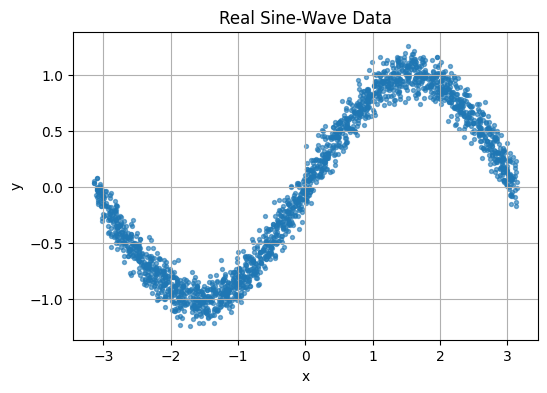

In [3]:
# Step 1.1: Creating real sine-wave 2D data


def generate_sine_data(n_samples=2000):
    x = np.random.uniform(-np.pi, np.pi, n_samples)
    y = np.sin(x) + np.random.normal(0, 0.1, n_samples)
    data = np.column_stack((x, y))
    return data.astype(np.float32)

real_sine_data = generate_sine_data(2000)

plt.figure(figsize=(6, 4))
plt.scatter(real_sine_data[:, 0], real_sine_data[:, 1], s=8, alpha=0.6)
plt.title("Real Sine-Wave Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.savefig("figures/part1_real_sine_data.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.2 Build Generator and Discriminator

In [4]:
# Step 1.2: Define GAN model architecture


class Generator2D(nn.Module):
    def __init__(self, noise_dim=2):
        super(Generator2D, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator2D(nn.Module):
    def __init__(self):
        super(Discriminator2D, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## 1.3 Train sine-wave GAN

In [5]:
# Training GAN on sine-wave data

# Prepare DataLoader
batch_size = 64
real_tensor = torch.tensor(real_sine_data)
dataset = TensorDataset(real_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Hyperparameters
noise_dim = 2
lr = 0.0002
epochs = 3000

# Initialise models
G_sine = Generator2D(noise_dim).to(device)
D_sine = Discriminator2D().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G_sine.parameters(), lr=lr)
optimizer_D = optim.Adam(D_sine.parameters(), lr=lr)

g_losses = []
d_losses = []

for epoch in range(epochs):
    for real_batch, in loader:
        real_batch = real_batch.to(device)
        batch_size_current = real_batch.size(0)

        # Labels
        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_sine(z)

        real_output = D_sine(real_batch)
        fake_output = D_sine(fake_batch.detach())

        d_loss_real = criterion(real_output, real_labels)
        d_loss_fake = criterion(fake_output, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_sine(z)
        fake_output = D_sine(fake_batch)

        g_loss = criterion(fake_output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [500/3000] | D Loss: 1.3875 | G Loss: 0.6974
Epoch [1000/3000] | D Loss: 1.3861 | G Loss: 0.6917
Epoch [1500/3000] | D Loss: 1.3834 | G Loss: 0.6953
Epoch [2000/3000] | D Loss: 1.3858 | G Loss: 0.6922
Epoch [2500/3000] | D Loss: 1.3869 | G Loss: 0.6932
Epoch [3000/3000] | D Loss: 1.3866 | G Loss: 0.6916


## 1.4 Plot loss curves

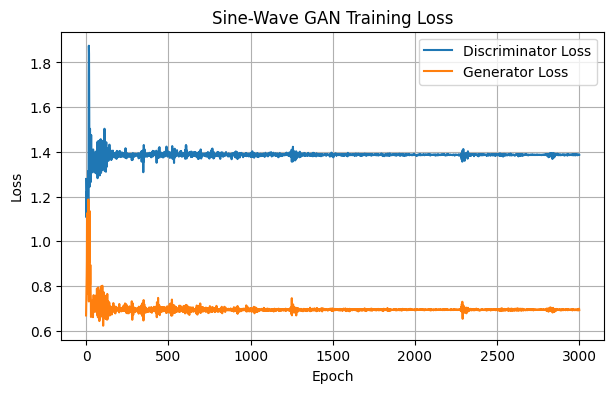

In [6]:
# Step 1.4: Plot GAN training losses

plt.figure(figsize=(7, 4))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.title("Sine-Wave GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("figures/part1_sine_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.5 Generate fake sine-wave samples

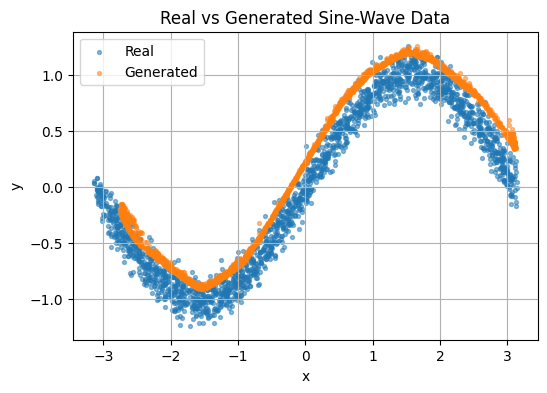

In [7]:
# Step 1.5: Generate fake sine-wave samples

G_sine.eval()

with torch.no_grad():
    z = torch.randn(2000, noise_dim).to(device)
    generated_sine = G_sine(z).cpu().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(real_sine_data[:, 0], real_sine_data[:, 1], s=8, alpha=0.5, label="Real")
plt.scatter(generated_sine[:, 0], generated_sine[:, 1], s=8, alpha=0.5, label="Generated")
plt.title("Real vs Generated Sine-Wave Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.savefig("figures/part1_real_vs_generated_sine.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 1.6 — New 2D Distribution

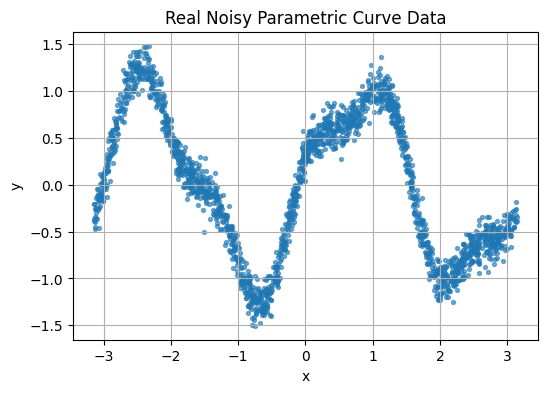

In [8]:
# Creating noisy parametric curve 2D distribution
# y = sin(2x) + 0.3cos(5x) + epsilon

def generate_noisy_curve_data(n_samples=2000):
    x = np.random.uniform(-np.pi, np.pi, n_samples)
    epsilon = np.random.normal(0, 0.12, n_samples)
    y = np.sin(2 * x) + 0.3 * np.cos(5 * x) + epsilon
    data = np.column_stack((x, y))
    return data.astype(np.float32)

real_curve_data = generate_noisy_curve_data(2000)

plt.figure(figsize=(6, 4))
plt.scatter(real_curve_data[:, 0], real_curve_data[:, 1], s=8, alpha=0.6)
plt.title("Real Noisy Parametric Curve Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.savefig("figures/part1_real_noisy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 1.7 — Train GAN on New Distribution

In [9]:
# Train original GAN architecture on noisy curve

batch_size = 64
curve_tensor = torch.tensor(real_curve_data)
curve_dataset = TensorDataset(curve_tensor)
curve_loader = DataLoader(curve_dataset, batch_size=batch_size, shuffle=True)

noise_dim = 2
lr = 0.0002
epochs = 3000

G_curve = Generator2D(noise_dim).to(device)
D_curve = Discriminator2D().to(device)

criterion = nn.BCELoss()
optimizer_G_curve = optim.Adam(G_curve.parameters(), lr=lr)
optimizer_D_curve = optim.Adam(D_curve.parameters(), lr=lr)

g_curve_losses = []
d_curve_losses = []

for epoch in range(epochs):
    for real_batch, in curve_loader:
        real_batch = real_batch.to(device)
        batch_size_current = real_batch.size(0)

        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_curve(z)

        real_output = D_curve(real_batch)
        fake_output = D_curve(fake_batch.detach())

        d_loss_real = criterion(real_output, real_labels)
        d_loss_fake = criterion(fake_output, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D_curve.zero_grad()
        d_loss.backward()
        optimizer_D_curve.step()

        # Train Generator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_curve(z)
        fake_output = D_curve(fake_batch)

        g_loss = criterion(fake_output, real_labels)

        optimizer_G_curve.zero_grad()
        g_loss.backward()
        optimizer_G_curve.step()

    g_curve_losses.append(g_loss.item())
    d_curve_losses.append(d_loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [500/3000] | D Loss: 1.4050 | G Loss: 0.6825
Epoch [1000/3000] | D Loss: 1.3662 | G Loss: 0.6927
Epoch [1500/3000] | D Loss: 1.3976 | G Loss: 0.7281
Epoch [2000/3000] | D Loss: 1.3901 | G Loss: 0.7144
Epoch [2500/3000] | D Loss: 1.3810 | G Loss: 0.6980
Epoch [3000/3000] | D Loss: 1.3773 | G Loss: 0.7007


## Step 1.8 — Visual Comparison

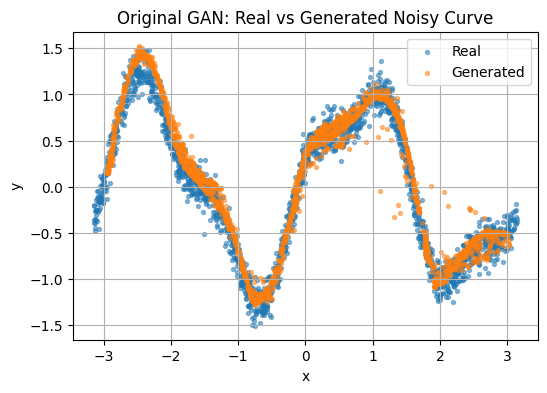

In [10]:
# Comparing real vs generated noisy curve samples

G_curve.eval()

with torch.no_grad():
    z = torch.randn(2000, noise_dim).to(device)
    generated_curve = G_curve(z).cpu().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(real_curve_data[:, 0], real_curve_data[:, 1], s=8, alpha=0.5, label="Real")
plt.scatter(generated_curve[:, 0], generated_curve[:, 1], s=8, alpha=0.5, label="Generated")
plt.title("Original GAN: Real vs Generated Noisy Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.savefig("figures/part1_original_gan_noisy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

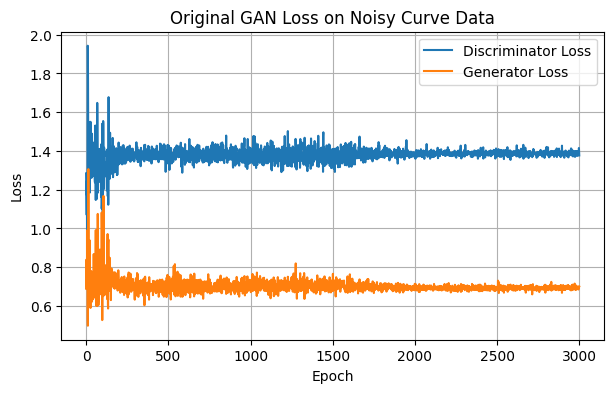

In [11]:
# Plot loss curve for noisy curve GAN

plt.figure(figsize=(7, 4))
plt.plot(d_curve_losses, label="Discriminator Loss")
plt.plot(g_curve_losses, label="Generator Loss")
plt.title("Original GAN Loss on Noisy Curve Data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("figures/part1_original_gan_noisy_curve_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 1.9 — Modified GAN Architecture

1. Increasing layer depth
2. Using LeakyReLU in the Generator
3. Adding BatchNorm to stabilise training

In [12]:
# Modified GAN architecture

class ModifiedGenerator2D(nn.Module):
    def __init__(self, noise_dim=2):
        super(ModifiedGenerator2D, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)


class ModifiedDiscriminator2D(nn.Module):
    def __init__(self):
        super(ModifiedDiscriminator2D, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Step 1.10 — Train Modified GAN

In [13]:
# Training modified GAN on noisy curve data

G_curve_mod = ModifiedGenerator2D(noise_dim).to(device)
D_curve_mod = ModifiedDiscriminator2D().to(device)

optimizer_G_curve_mod = optim.Adam(G_curve_mod.parameters(), lr=lr)
optimizer_D_curve_mod = optim.Adam(D_curve_mod.parameters(), lr=lr)

g_curve_mod_losses = []
d_curve_mod_losses = []

for epoch in range(epochs):
    for real_batch, in curve_loader:
        real_batch = real_batch.to(device)
        batch_size_current = real_batch.size(0)

        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_curve_mod(z)

        real_output = D_curve_mod(real_batch)
        fake_output = D_curve_mod(fake_batch.detach())

        d_loss_real = criterion(real_output, real_labels)
        d_loss_fake = criterion(fake_output, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D_curve_mod.zero_grad()
        d_loss.backward()
        optimizer_D_curve_mod.step()

        # Train Generator
        z = torch.randn(batch_size_current, noise_dim).to(device)
        fake_batch = G_curve_mod(z)
        fake_output = D_curve_mod(fake_batch)

        g_loss = criterion(fake_output, real_labels)

        optimizer_G_curve_mod.zero_grad()
        g_loss.backward()
        optimizer_G_curve_mod.step()

    g_curve_mod_losses.append(g_loss.item())
    d_curve_mod_losses.append(d_loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [500/3000] | D Loss: 1.3812 | G Loss: 0.7218
Epoch [1000/3000] | D Loss: 1.3605 | G Loss: 0.6912
Epoch [1500/3000] | D Loss: 1.3809 | G Loss: 0.6769
Epoch [2000/3000] | D Loss: 1.3818 | G Loss: 0.7133
Epoch [2500/3000] | D Loss: 1.3879 | G Loss: 0.7244
Epoch [3000/3000] | D Loss: 1.3804 | G Loss: 0.6985


## Step 1.11 — Compare Original vs Modified GAN

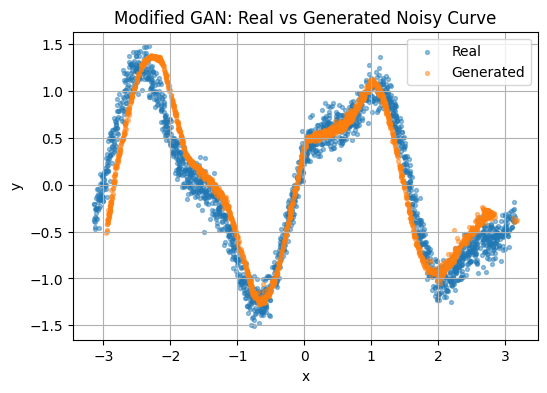

In [14]:
# Comparing original and modified GAN outputs

G_curve_mod.eval()

with torch.no_grad():
    z = torch.randn(2000, noise_dim).to(device)
    generated_curve_mod = G_curve_mod(z).cpu().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(real_curve_data[:, 0], real_curve_data[:, 1], s=8, alpha=0.45, label="Real")
plt.scatter(generated_curve_mod[:, 0], generated_curve_mod[:, 1], s=8, alpha=0.45, label="Generated")
plt.title("Modified GAN: Real vs Generated Noisy Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.savefig("figures/part1_modified_gan_noisy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Step 2 — Part 2.1: PneumoniaMNIST DCGAN

In [15]:
# Installing and importing MedMNIST

!pip install medmnist -q

import medmnist
from medmnist import INFO
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 1.6 MB/s eta 0:00:00


## 2.2 Load PneumoniaMNIST dataset

In [16]:
# Loading PneumoniaMNIST dataset

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = DataClass(split="train", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)

print("Dataset:", data_flag)
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Image size:", train_dataset[0][0].shape)
print("Labels:", info["label"])

100%|██████████| 4.17M/4.17M [00:07<00:00, 531kB/s]

Dataset: pneumoniamnist
Number of training samples: 4708
Number of test samples: 624
Image size: torch.Size([1, 28, 28])
Labels: {'0': 'normal', '1': 'pneumonia'}


## 2.3 Exploring class distribution

   Class  Count
0      0   1214
1      1   3494


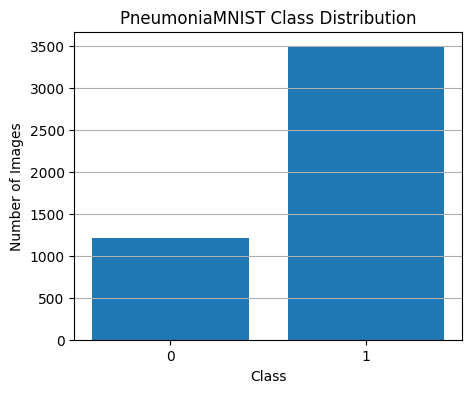

In [17]:
# Class distribution

labels = train_dataset.labels.flatten()

unique, counts = np.unique(labels, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Count": counts
})

print(class_distribution)

plt.figure(figsize=(5, 4))
plt.bar(class_distribution["Class"].astype(str), class_distribution["Count"])
plt.title("PneumoniaMNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y")
plt.savefig("figures/part2_1_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.4 Visualise real chest X-ray samples

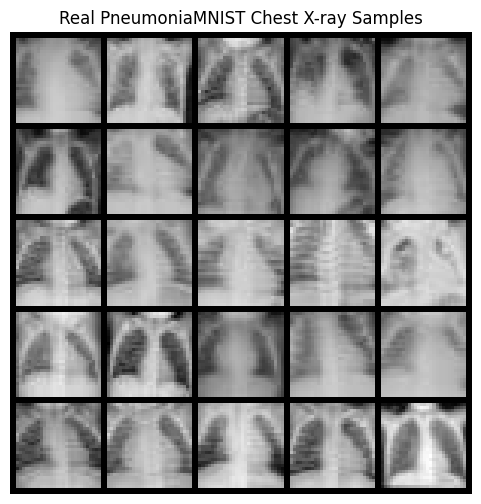

In [18]:
# Showing real PneumoniaMNIST samples

real_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

real_images, real_labels = next(iter(real_loader))

grid = make_grid(real_images[:25], nrow=5, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
plt.title("Real PneumoniaMNIST Chest X-ray Samples")
plt.axis("off")
plt.savefig("figures/part2_1_real_xray_samples.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.5 Build DCGAN Generator and Discriminator

In [20]:
# DCGAN architecture

class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=1):
        super(DCGANGenerator, self).__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self, img_channels=1):
        super(DCGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

## 2.6 Train DCGAN on PneumoniaMNIST

Epoch [1/30] | D Loss: 0.2700 | G Loss: 2.5427
Epoch [2/30] | D Loss: 0.4364 | G Loss: 2.1198
Epoch [3/30] | D Loss: 0.5753 | G Loss: 1.2427
Epoch [4/30] | D Loss: 0.9890 | G Loss: 1.2460
Epoch [5/30] | D Loss: 1.0025 | G Loss: 0.9442
Epoch [6/30] | D Loss: 0.9490 | G Loss: 1.2394
Epoch [7/30] | D Loss: 0.8760 | G Loss: 1.0259
Epoch [8/30] | D Loss: 0.8942 | G Loss: 1.4724
Epoch [9/30] | D Loss: 1.0687 | G Loss: 1.6331
Epoch [10/30] | D Loss: 1.0356 | G Loss: 1.1789


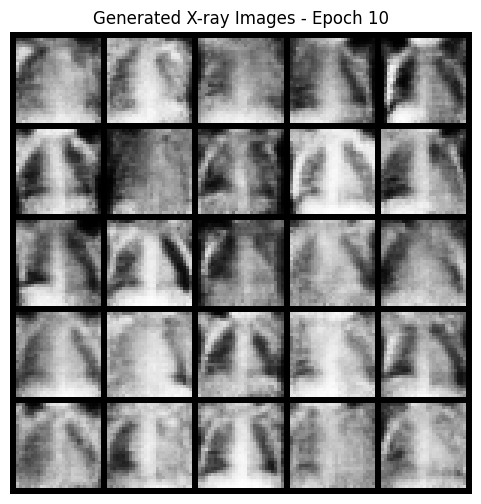

Epoch [11/30] | D Loss: 1.0604 | G Loss: 1.1600
Epoch [12/30] | D Loss: 0.9345 | G Loss: 1.3473
Epoch [13/30] | D Loss: 0.7695 | G Loss: 1.6355
Epoch [14/30] | D Loss: 1.0287 | G Loss: 1.8308
Epoch [15/30] | D Loss: 0.8087 | G Loss: 1.8588
Epoch [16/30] | D Loss: 0.7514 | G Loss: 1.1924
Epoch [17/30] | D Loss: 0.7226 | G Loss: 1.6903
Epoch [18/30] | D Loss: 0.5121 | G Loss: 1.6796
Epoch [19/30] | D Loss: 0.9289 | G Loss: 1.5353
Epoch [20/30] | D Loss: 0.5319 | G Loss: 1.7791


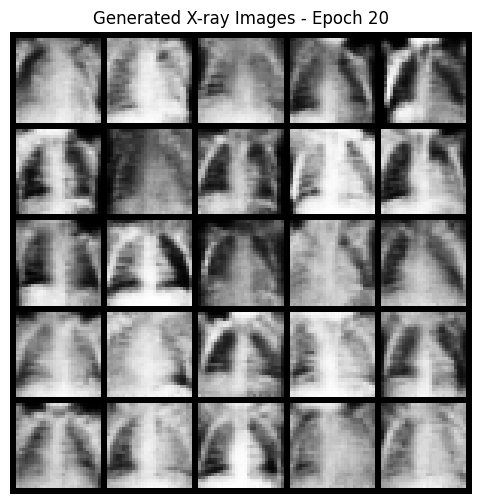

Epoch [21/30] | D Loss: 0.6323 | G Loss: 1.4705
Epoch [22/30] | D Loss: 0.7440 | G Loss: 2.1158
Epoch [23/30] | D Loss: 1.0684 | G Loss: 1.6153
Epoch [24/30] | D Loss: 0.3921 | G Loss: 1.8261
Epoch [25/30] | D Loss: 0.5374 | G Loss: 1.5822
Epoch [26/30] | D Loss: 1.0702 | G Loss: 0.7065
Epoch [27/30] | D Loss: 0.5119 | G Loss: 1.5042
Epoch [28/30] | D Loss: 0.7506 | G Loss: 2.8607
Epoch [29/30] | D Loss: 0.4895 | G Loss: 2.0800
Epoch [30/30] | D Loss: 0.7222 | G Loss: 1.9413


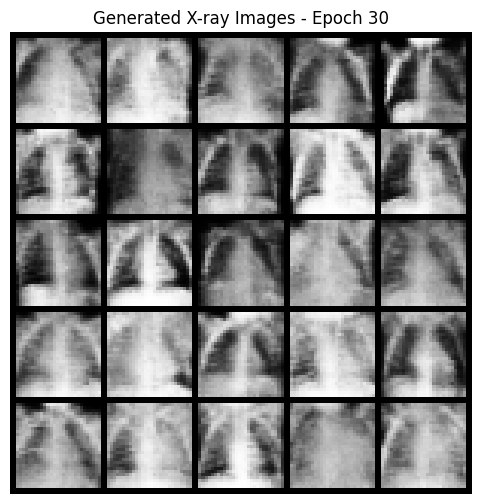

In [21]:
# Train DCGAN

batch_size = 128
latent_dim = 100
lr = 0.0002
epochs = 30

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

G_xray = DCGANGenerator(latent_dim=latent_dim, img_channels=1).to(device)
D_xray = DCGANDiscriminator(img_channels=1).to(device)

criterion = nn.BCELoss()

optimizer_G_xray = optim.Adam(G_xray.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_xray = optim.Adam(D_xray.parameters(), lr=lr, betas=(0.5, 0.999))

g_xray_losses = []
d_xray_losses = []

fixed_noise = torch.randn(25, latent_dim, 1, 1).to(device)

for epoch in range(epochs):
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        current_batch_size = real_imgs.size(0)

        real_labels = torch.ones(current_batch_size, 1).to(device)
        fake_labels = torch.zeros(current_batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(current_batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = G_xray(z)

        real_outputs = D_xray(real_imgs)
        fake_outputs = D_xray(fake_imgs.detach())

        d_loss_real = criterion(real_outputs, real_labels)
        d_loss_fake = criterion(fake_outputs, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D_xray.zero_grad()
        d_loss.backward()
        optimizer_D_xray.step()

        # Train Generator
        z = torch.randn(current_batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = G_xray(z)
        fake_outputs = D_xray(fake_imgs)

        g_loss = criterion(fake_outputs, real_labels)

        optimizer_G_xray.zero_grad()
        g_loss.backward()
        optimizer_G_xray.step()

    g_xray_losses.append(g_loss.item())
    d_xray_losses.append(d_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Saving generated images every 10 epochs
    if (epoch + 1) % 10 == 0:
        G_xray.eval()
        with torch.no_grad():
            sample_imgs = G_xray(fixed_noise).cpu()
        grid = make_grid(sample_imgs, nrow=5, normalize=True)

        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
        plt.title(f"Generated X-ray Images - Epoch {epoch+1}")
        plt.axis("off")
        plt.savefig(f"figures/part2_1_generated_epoch_{epoch+1}.png", dpi=300, bbox_inches="tight")
        plt.show()
        G_xray.train()

## 2.7 Plot training loss curves

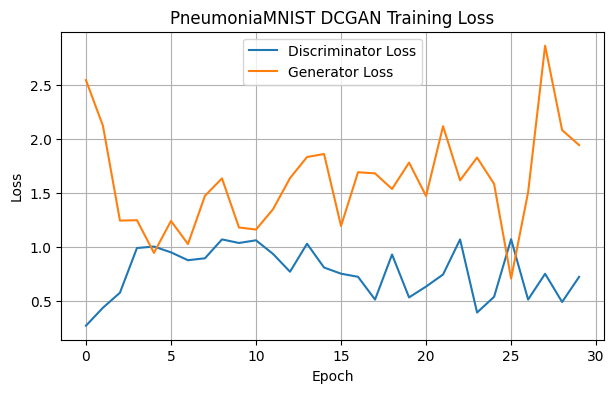

In [22]:
# Plotting DCGAN loss curves

plt.figure(figsize=(7, 4))
plt.plot(d_xray_losses, label="Discriminator Loss")
plt.plot(g_xray_losses, label="Generator Loss")
plt.title("PneumoniaMNIST DCGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("figures/part2_1_xray_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.8 Generating final fake X-ray images

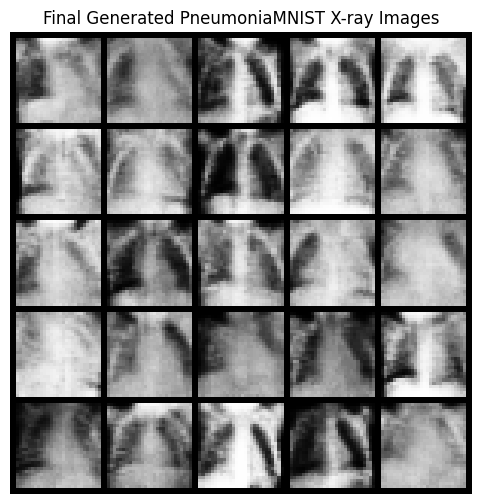

In [23]:
# Generating final fake X-ray images

G_xray.eval()

with torch.no_grad():
    z = torch.randn(25, latent_dim, 1, 1).to(device)
    fake_xray_images = G_xray(z).cpu()

grid = make_grid(fake_xray_images, nrow=5, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.title("Final Generated PneumoniaMNIST X-ray Images")
plt.axis("off")
plt.savefig("figures/part2_1_final_generated_xray.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.9 Real vs fake visual comparison

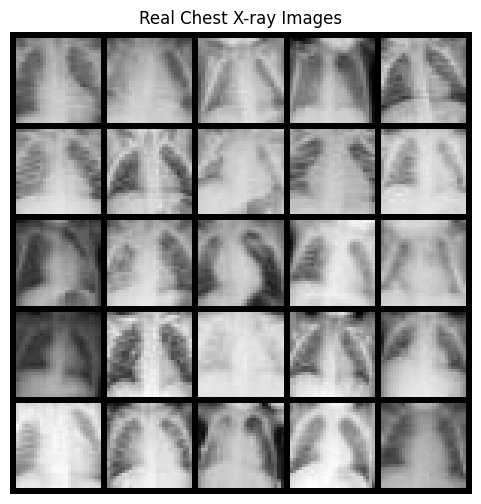

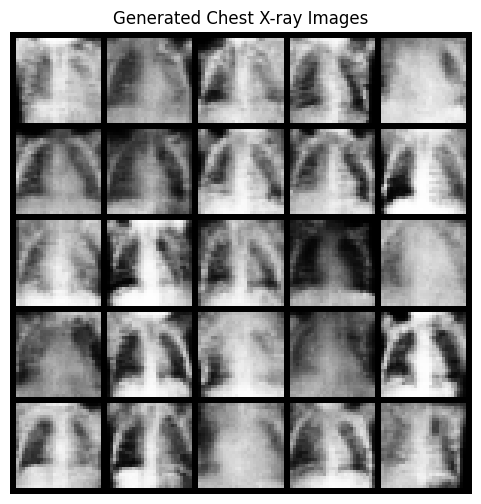

In [24]:
# Real vs fake comparison

real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:25].cpu()

with torch.no_grad():
    z = torch.randn(25, latent_dim, 1, 1).to(device)
    fake_batch = G_xray(z).cpu()

real_grid = make_grid(real_batch, nrow=5, normalize=True)
fake_grid = make_grid(fake_batch, nrow=5, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(real_grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.title("Real Chest X-ray Images")
plt.axis("off")
plt.savefig("figures/part2_1_real_xray_grid.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(fake_grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.title("Generated Chest X-ray Images")
plt.axis("off")
plt.savefig("figures/part2_1_fake_xray_grid.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.10 Simple quantitative comparison

In [25]:
# Basic quantitative comparison

real_mean = real_batch.mean().item()
real_std = real_batch.std().item()

fake_mean = fake_batch.mean().item()
fake_std = fake_batch.std().item()

comparison_df = pd.DataFrame({
    "Dataset": ["Real X-rays", "Generated X-rays"],
    "Mean Pixel Value": [real_mean, fake_mean],
    "Pixel Standard Deviation": [real_std, fake_std]
})

print(comparison_df)

comparison_df.to_csv("results/part2_1_real_fake_pixel_comparison.csv", index=False)

            Dataset  Mean Pixel Value  Pixel Standard Deviation
0       Real X-rays          0.163501                  0.345812
1  Generated X-rays          0.126724                  0.493019


## 2.11 Optional FID-style metric

In [26]:
# Simplified distribution distance

from scipy.linalg import sqrtm

def calculate_simple_fid(real_images, fake_images):
    real_flat = real_images.view(real_images.size(0), -1).numpy()
    fake_flat = fake_images.view(fake_images.size(0), -1).numpy()

    mu_real = np.mean(real_flat, axis=0)
    mu_fake = np.mean(fake_flat, axis=0)

    sigma_real = np.cov(real_flat, rowvar=False)
    sigma_fake = np.cov(fake_flat, rowvar=False)

    diff = mu_real - mu_fake

    covmean = sqrtm(sigma_real.dot(sigma_fake))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

simple_fid_xray = calculate_simple_fid(real_batch, fake_batch)

print("Simplified FID-style score:", simple_fid_xray)

with open("results/part2_1_simple_fid_score.txt", "w") as f:
    f.write(f"Simplified FID-style score: {simple_fid_xray}")

Simplified FID-style score: 62.370017241404625


# Step 3 — Part 2.2: CICIDS 2017 Tabular GAN

# NOTE:
## The CICIDS 2017 Wednesday CSV file is manually uploaded in Colab.
## The marker should download the file from Kaggle:
## https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset/data
## Required file: Wednesday-workingHours.pcap_ISCX.csv

In [27]:
# Step 3.1: Loading CICIDS 2017 Wednesday file

from google.colab import files
uploaded = files.upload()

Saving Wednesday-workingHours.pcap_ISCX.csv to Wednesday-workingHours.pcap_ISCX (1).csv


In [28]:
import os

print(os.listdir())

['.config', 'figures', 'Wednesday-workingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX (1).csv', 'results', 'models', 'sample_data']


In [29]:
cicids_file = "Wednesday-workingHours.pcap_ISCX.csv"

df_cic = pd.read_csv(cicids_file)

print("Dataset shape:", df_cic.shape)
df_cic.head()

Dataset shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## ## 3.2 Cleaning column names

In [30]:
df_cic.columns = df_cic.columns.str.strip()

print(df_cic.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

## 3.3 Exploring labels and class balance

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


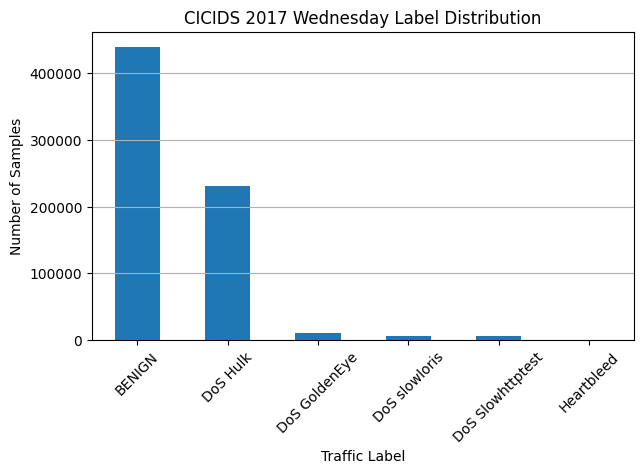

In [31]:
# Exploring label distribution

print(df_cic["Label"].value_counts())

plt.figure(figsize=(7, 4))
df_cic["Label"].value_counts().plot(kind="bar")
plt.title("CICIDS 2017 Wednesday Label Distribution")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.savefig("figures/part2_2_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.4 Filter BENIGN and DoS/DDoS labels

In [32]:
# Filter BENIGN and DoS traffic

selected_labels = df_cic["Label"].astype(str).str.contains("BENIGN|DoS", case=False, regex=True)

df_cic_filtered = df_cic[selected_labels].copy()

print("Filtered shape:", df_cic_filtered.shape)
print(df_cic_filtered["Label"].value_counts())

Filtered shape: (692692, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


## 3.5 Convert labels to binary

In [35]:
# Binary label encoding
# BENIGN = 0, DoS/DDoS = 1

df_cic_filtered["binary_label"] = df_cic_filtered["Label"].apply(
    lambda x: 0 if str(x).upper() == "BENIGN" else 1
)

print(df_cic_filtered["binary_label"].value_counts())

binary_label
0    440031
1    252661
Name: count, dtype: int64


## 3.6 Preprocess numerical features

In [36]:
# Cleaning and preprocess features

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop original label columns
feature_df = df_cic_filtered.drop(columns=["Label", "binary_label"])

# Keep numeric columns only
feature_df = feature_df.select_dtypes(include=[np.number])

# Replace infinite values
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

# Fill missing values using median
feature_df = feature_df.fillna(feature_df.median())

# Remove constant columns
constant_cols = [col for col in feature_df.columns if feature_df[col].nunique() <= 1]
feature_df = feature_df.drop(columns=constant_cols)

print("Final feature shape:", feature_df.shape)
print("Removed constant columns:", len(constant_cols))

labels_cic = df_cic_filtered["binary_label"].values

scaler_cic = StandardScaler()
X_cic_scaled = scaler_cic.fit_transform(feature_df)

print("Scaled data shape:", X_cic_scaled.shape)

Final feature shape: (692692, 68)
Removed constant columns: 10
Scaled data shape: (692692, 68)


## 3.7 Sample data for faster training

In [37]:
# Balanced sample for GAN training

df_features_scaled = pd.DataFrame(X_cic_scaled, columns=feature_df.columns)
df_features_scaled["binary_label"] = labels_cic

benign_data = df_features_scaled[df_features_scaled["binary_label"] == 0]
dos_data = df_features_scaled[df_features_scaled["binary_label"] == 1]

sample_size = min(10000, len(benign_data), len(dos_data))

benign_sample = benign_data.sample(sample_size, random_state=SEED)
dos_sample = dos_data.sample(sample_size, random_state=SEED)

gan_train_df = pd.concat([benign_sample, dos_sample], axis=0).sample(frac=1, random_state=SEED)

X_gan_tabular = gan_train_df.drop(columns=["binary_label"]).values.astype(np.float32)

print("GAN training data shape:", X_gan_tabular.shape)

GAN training data shape: (20000, 68)


## 3.8 Create DataLoader

In [39]:
# Creating DataLoader for tabular GAN

tabular_tensor = torch.tensor(X_gan_tabular, dtype=torch.float32)

tabular_dataset = TensorDataset(tabular_tensor)
tabular_loader = DataLoader(tabular_dataset, batch_size=128, shuffle=True)

input_dim = X_gan_tabular.shape[1]

print("Number of input features:", input_dim)

Number of input features: 68


## 3.9 Build tabular GAN

In [40]:
# Tabular GAN architecture

class TabularGenerator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super(TabularGenerator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class TabularDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super(TabularDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## 3.10 Train tabular GAN

In [41]:
# Training tabular GAN

noise_dim_tabular = 64
epochs = 100
lr = 0.0002

G_tabular = TabularGenerator(noise_dim_tabular, input_dim).to(device)
D_tabular = TabularDiscriminator(input_dim).to(device)

criterion = nn.BCELoss()

optimizer_G_tabular = optim.Adam(G_tabular.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_tabular = optim.Adam(D_tabular.parameters(), lr=lr, betas=(0.5, 0.999))

g_tabular_losses = []
d_tabular_losses = []

for epoch in range(epochs):
    for real_batch, in tabular_loader:
        real_batch = real_batch.to(device)
        current_batch_size = real_batch.size(0)

        real_labels = torch.ones(current_batch_size, 1).to(device)
        fake_labels = torch.zeros(current_batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(current_batch_size, noise_dim_tabular).to(device)
        fake_batch = G_tabular(z)

        real_outputs = D_tabular(real_batch)
        fake_outputs = D_tabular(fake_batch.detach())

        d_loss_real = criterion(real_outputs, real_labels)
        d_loss_fake = criterion(fake_outputs, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D_tabular.zero_grad()
        d_loss.backward()
        optimizer_D_tabular.step()

        # Train Generator
        z = torch.randn(current_batch_size, noise_dim_tabular).to(device)
        fake_batch = G_tabular(z)
        fake_outputs = D_tabular(fake_batch)

        g_loss = criterion(fake_outputs, real_labels)

        optimizer_G_tabular.zero_grad()
        g_loss.backward()
        optimizer_G_tabular.step()

    g_tabular_losses.append(g_loss.item())
    d_tabular_losses.append(d_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [10/100] | D Loss: 0.8497 | G Loss: 1.0956
Epoch [20/100] | D Loss: 0.9559 | G Loss: 1.7400
Epoch [30/100] | D Loss: 0.6589 | G Loss: 1.7620
Epoch [40/100] | D Loss: 0.6573 | G Loss: 1.5038
Epoch [50/100] | D Loss: 0.7961 | G Loss: 2.0426
Epoch [60/100] | D Loss: 0.7091 | G Loss: 2.1922
Epoch [70/100] | D Loss: 0.5809 | G Loss: 1.7622
Epoch [80/100] | D Loss: 0.5201 | G Loss: 1.5515
Epoch [90/100] | D Loss: 0.8227 | G Loss: 2.4263
Epoch [100/100] | D Loss: 0.9210 | G Loss: 1.4341


## 3.11 Plot tabular GAN losses

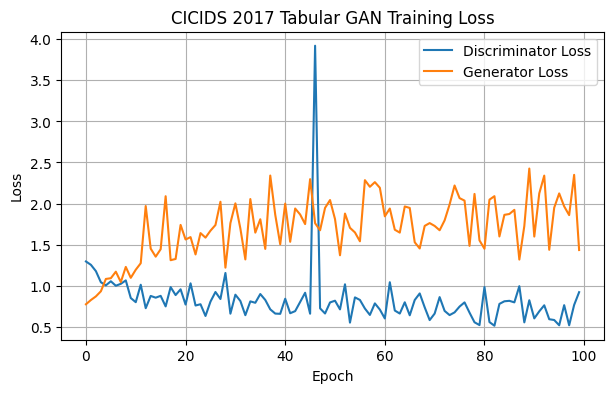

In [42]:
# Plotting tabular GAN loss curves

plt.figure(figsize=(7, 4))
plt.plot(d_tabular_losses, label="Discriminator Loss")
plt.plot(g_tabular_losses, label="Generator Loss")
plt.title("CICIDS 2017 Tabular GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("figures/part2_2_tabular_gan_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.12 Generate synthetic network traffic

In [43]:
# Generating synthetic traffic samples

G_tabular.eval()

n_fake_samples = X_gan_tabular.shape[0]

with torch.no_grad():
    z = torch.randn(n_fake_samples, noise_dim_tabular).to(device)
    fake_tabular = G_tabular(z).cpu().numpy()

print("Generated synthetic traffic shape:", fake_tabular.shape)

Generated synthetic traffic shape: (20000, 68)


## 3.13 PCA comparison: real vs generated

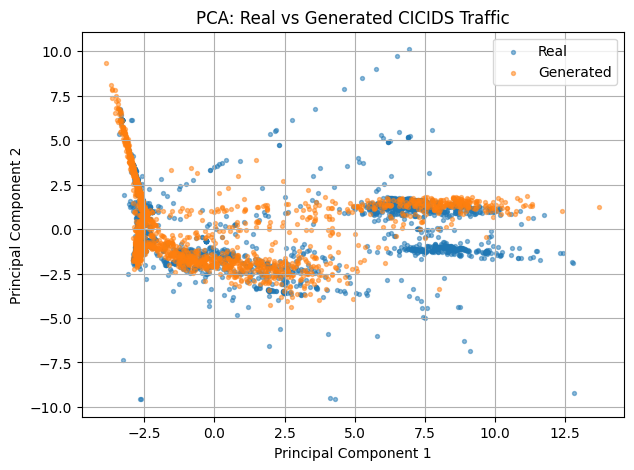

In [44]:
# PCA visual comparison

from sklearn.decomposition import PCA

n_compare = min(3000, X_gan_tabular.shape[0])

real_compare = X_gan_tabular[:n_compare]
fake_compare = fake_tabular[:n_compare]

combined_data = np.vstack([real_compare, fake_compare])

pca = PCA(n_components=2, random_state=SEED)
pca_result = pca.fit_transform(combined_data)

real_pca = pca_result[:n_compare]
fake_pca = pca_result[n_compare:]

plt.figure(figsize=(7, 5))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.5, label="Real")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.5, label="Generated")
plt.title("PCA: Real vs Generated CICIDS Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.savefig("figures/part2_2_pca_real_vs_generated.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.14 Quantitative distribution comparison

In [45]:
# Quantitative feature comparison

real_mean = np.mean(real_compare, axis=0)
fake_mean = np.mean(fake_compare, axis=0)

real_std = np.std(real_compare, axis=0)
fake_std = np.std(fake_compare, axis=0)

mean_absolute_difference = np.mean(np.abs(real_mean - fake_mean))
std_absolute_difference = np.mean(np.abs(real_std - fake_std))

print("Mean absolute difference between real and fake feature means:", mean_absolute_difference)
print("Mean absolute difference between real and fake feature standard deviations:", std_absolute_difference)

tabular_comparison = pd.DataFrame({
    "Metric": [
        "Mean absolute difference of feature means",
        "Mean absolute difference of feature standard deviations"
    ],
    "Value": [
        mean_absolute_difference,
        std_absolute_difference
    ]
})

tabular_comparison.to_csv("results/part2_2_tabular_distribution_comparison.csv", index=False)

tabular_comparison

Mean absolute difference between real and fake feature means: 0.18467128
Mean absolute difference between real and fake feature standard deviations: 0.44368273


,Metric,Value
0,Mean absolute difference of feature means,0.184671
1,Mean absolute difference of feature standard d...,0.443683


# Step 4 — Part 2.3: QuickDraw Broccoli DCGAN

## 4.1 Download QuickDraw Broccoli Dataset

In [46]:
# Download QuickDraw Broccoli Dataset

!wget https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/broccoli.npy

--2026-06-24 12:18:42--  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/broccoli.npy
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.97.207, 108.177.125.207, 142.250.157.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.97.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 104135664 (99M) [application/octet-stream]
Saving to: ‘broccoli.npy’

broccoli.npy        100%[===================>]  99.31M  23.0MB/s    in 5.3s    

2026-06-24 12:18:48 (18.6 MB/s) - ‘broccoli.npy’ saved [104135664/104135664]



In [47]:
# Load the Dataset
import numpy as np

broccoli_data = np.load("broccoli.npy")

print("Dataset shape:", broccoli_data.shape)

Dataset shape: (132826, 784)


## 4.2 Exploring Dataset

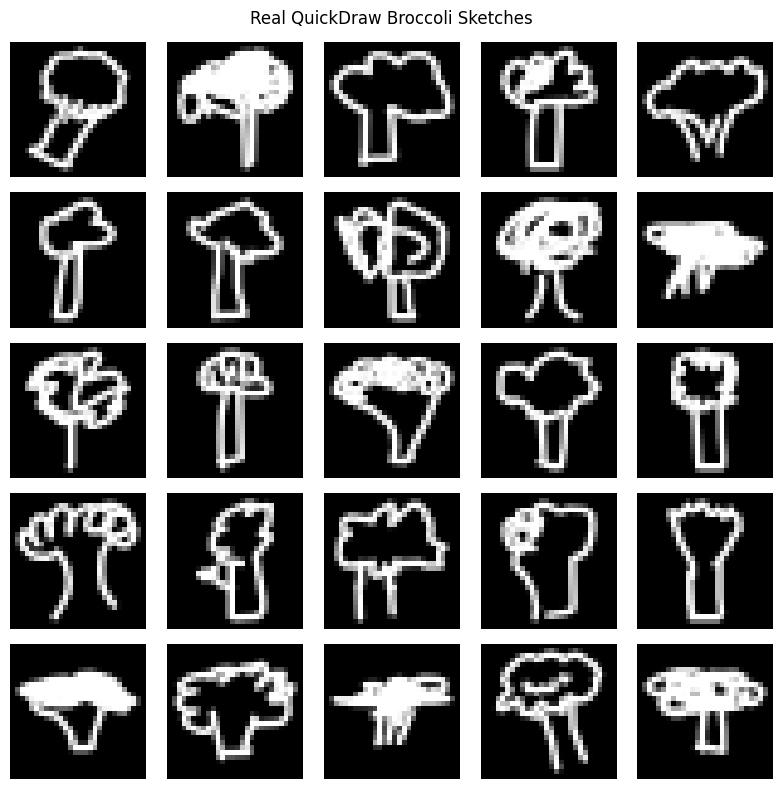

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for i in range(25):
    plt.subplot(5,5,i+1)

    img = broccoli_data[i].reshape(28,28)

    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle("Real QuickDraw Broccoli Sketches")
plt.tight_layout()

plt.savefig(
    "figures/part2_3_real_broccoli_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.3 Preparing Dataset

In [49]:
sample_size = 20000

broccoli_subset = broccoli_data[:sample_size]

broccoli_subset = broccoli_subset.astype(np.float32)

# Scale to [-1,1]
broccoli_subset = (broccoli_subset / 127.5) - 1.0

broccoli_subset = broccoli_subset.reshape(-1,1,28,28)

print(broccoli_subset.shape)

(20000, 1, 28, 28)


## Create DataLoader

In [50]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

broccoli_tensor = torch.tensor(
    broccoli_subset,
    dtype=torch.float32
)

broccoli_dataset = TensorDataset(broccoli_tensor)

broccoli_loader = DataLoader(
    broccoli_dataset,
    batch_size=128,
    shuffle=True
)

## 4.4 Build Broccoli DCGAN

In [51]:
# Generator

class BroccoliGenerator(nn.Module):

    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                latent_dim,128,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self,z):
        return self.model(z)

## Discriminator

In [52]:
# Discriminator

class BroccoliDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(0.2),

            nn.Flatten(),

            nn.Linear(
                128*7*7,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

## 4.5 Initialise Models

In [53]:
latent_dim = 100

G_broccoli = BroccoliGenerator(
    latent_dim
).to(device)

D_broccoli = BroccoliDiscriminator().to(device)

criterion = nn.BCELoss()

optimizer_G_broccoli = optim.Adam(
    G_broccoli.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

optimizer_D_broccoli = optim.Adam(
    D_broccoli.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

## 4.6 Train Broccoli DCGAN

In [54]:
epochs = 30

g_broccoli_losses = []
d_broccoli_losses = []

for epoch in range(epochs):

    for real_imgs, in broccoli_loader:

        real_imgs = real_imgs.to(device)

        batch_size_current = real_imgs.size(0)

        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # Train D

        z = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_imgs = G_broccoli(z)

        d_real = D_broccoli(real_imgs)
        d_fake = D_broccoli(fake_imgs.detach())

        d_loss_real = criterion(
            d_real,
            real_labels
        )

        d_loss_fake = criterion(
            d_fake,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        optimizer_D_broccoli.zero_grad()
        d_loss.backward()
        optimizer_D_broccoli.step()

        # Train G

        z = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_imgs = G_broccoli(z)

        g_loss = criterion(
            D_broccoli(fake_imgs),
            real_labels
        )

        optimizer_G_broccoli.zero_grad()
        g_loss.backward()
        optimizer_G_broccoli.step()

    g_broccoli_losses.append(
        g_loss.item()
    )

    d_broccoli_losses.append(
        d_loss.item()
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"D={d_loss.item():.4f} "
        f"G={g_loss.item():.4f}"
    )

Epoch 1/30 D=0.0053 G=5.8135
Epoch 2/30 D=0.6460 G=2.5286
Epoch 3/30 D=0.8882 G=1.7215
Epoch 4/30 D=0.5832 G=1.5814
Epoch 5/30 D=0.4093 G=1.3919
Epoch 6/30 D=0.4191 G=1.8751
Epoch 7/30 D=0.3548 G=1.6735
Epoch 8/30 D=0.4385 G=3.4780
Epoch 9/30 D=0.2749 G=2.5709
Epoch 10/30 D=0.2201 G=2.9252
Epoch 11/30 D=0.2612 G=1.5514
Epoch 12/30 D=0.2078 G=2.6872
Epoch 13/30 D=0.2321 G=3.0784
Epoch 14/30 D=0.2272 G=3.9855
Epoch 15/30 D=0.2664 G=3.2322
Epoch 16/30 D=0.3028 G=3.7102
Epoch 17/30 D=0.3366 G=1.3699
Epoch 18/30 D=0.1694 G=3.5267
Epoch 19/30 D=0.2305 G=2.2514
Epoch 20/30 D=0.1754 G=2.9661
Epoch 21/30 D=0.1914 G=2.6201
Epoch 22/30 D=0.2421 G=2.0276
Epoch 23/30 D=0.2291 G=3.8097
Epoch 24/30 D=0.5569 G=1.4347
Epoch 25/30 D=0.2698 G=2.8978
Epoch 26/30 D=0.1521 G=2.3075
Epoch 27/30 D=0.1498 G=4.4240
Epoch 28/30 D=0.4627 G=2.3244
Epoch 29/30 D=0.2673 G=2.1088
Epoch 30/30 D=0.2473 G=2.6848


## 4.7 Plot Training Curves

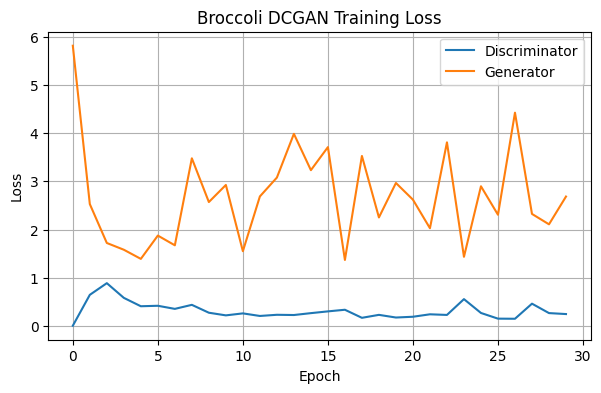

In [55]:
plt.figure(figsize=(7,4))

plt.plot(
    d_broccoli_losses,
    label="Discriminator"
)

plt.plot(
    g_broccoli_losses,
    label="Generator"
)

plt.legend()

plt.title(
    "Broccoli DCGAN Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig(
    "figures/part2_3_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.8 Generate Fake Broccoli Sketches

In [56]:
G_broccoli.eval()

with torch.no_grad():

    z = torch.randn(
        25,
        latent_dim,
        1,
        1
    ).to(device)

    fake_sketches = G_broccoli(z)

fake_sketches = fake_sketches.cpu()

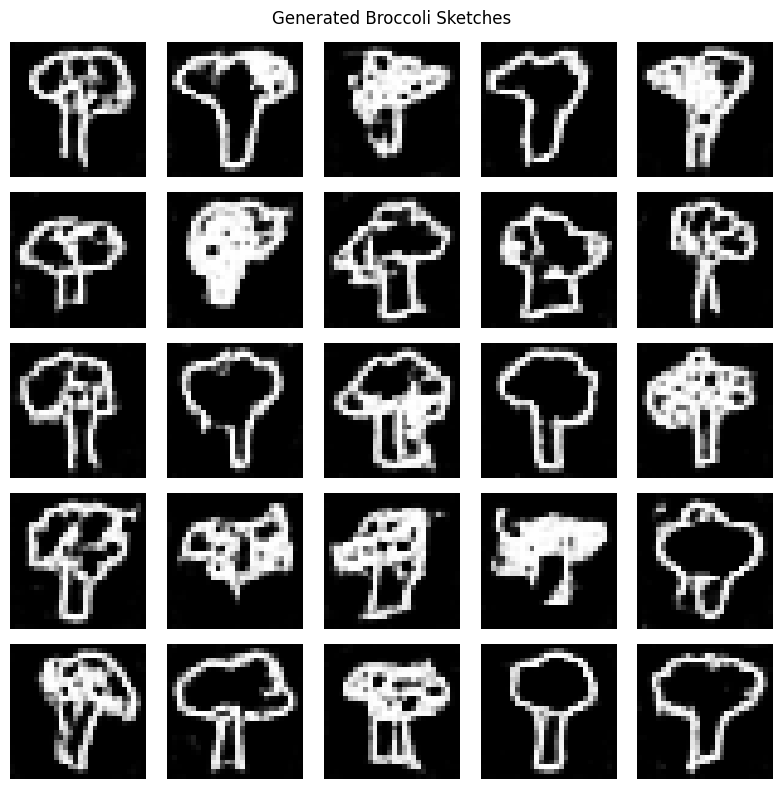

In [57]:
plt.figure(figsize=(8,8))

for i in range(25):

    plt.subplot(5,5,i+1)

    img = fake_sketches[i][0]

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Generated Broccoli Sketches"
)

plt.tight_layout()

plt.savefig(
    "figures/part2_3_generated_broccoli.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.9 PCA/FID-style Comparison

In [58]:
real_mean = broccoli_tensor.mean().item()
real_std = broccoli_tensor.std().item()

fake_mean = fake_sketches.mean().item()
fake_std = fake_sketches.std().item()

print("Real Mean:",real_mean)
print("Real Std:",real_std)

print("Fake Mean:",fake_mean)
print("Fake Std:",fake_std)

Real Mean: -0.5714724659919739
Real Std: 0.7257760167121887
Fake Mean: -0.5722792148590088
Fake Std: 0.7186195254325867


In [62]:
# Step 4.10: Simplified FID-style score for Broccoli

# Taking same number of real and fake samples
real_broccoli_batch = broccoli_tensor[:25].cpu()
fake_broccoli_batch = fake_sketches[:25].cpu()

simple_fid_broccoli = calculate_simple_fid(
    real_broccoli_batch,
    fake_broccoli_batch
)

print("Simplified FID-style score for broccoli:", simple_fid_broccoli)

with open("results/part2_3_simple_fid_score.txt", "w") as f:
    f.write(f"Simplified FID-style score for broccoli: {simple_fid_broccoli}")

Simplified FID-style score for broccoli: 302.71505202241246


/tmp/ipykernel_4512/1100277027.py:17: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma_real.dot(sigma_fake))


In [63]:
# Step 4.11: Broccoli real vs fake quantitative table

broccoli_comparison_df = pd.DataFrame({
    "Dataset": ["Real Broccoli Sketches", "Generated Broccoli Sketches"],
    "Mean Pixel Value": [real_mean, fake_mean],
    "Pixel Standard Deviation": [real_std, fake_std]
})

print(broccoli_comparison_df)

broccoli_comparison_df.to_csv(
    "results/part2_3_real_fake_pixel_comparison.csv",
    index=False
)

                       Dataset  Mean Pixel Value  Pixel Standard Deviation
0       Real Broccoli Sketches         -0.571472                  0.725776
1  Generated Broccoli Sketches         -0.572279                  0.718620


In [64]:
# Final Summary Table

summary_results = pd.DataFrame({
    "Assignment Section": [
        "Part 1 - Sine-wave GAN",
        "Part 1 - Noisy Curve GAN",
        "Part 2.1 - PneumoniaMNIST DCGAN",
        "Part 2.2 - CICIDS Tabular GAN",
        "Part 2.3 - Broccoli DCGAN"
    ],
    "Main Output": [
        "Generated 2D sine-wave samples",
        "Original vs modified GAN comparison",
        "Generated synthetic chest X-ray images",
        "Generated synthetic network traffic feature vectors",
        "Generated synthetic broccoli sketches"
    ],
    "Evaluation Used": [
        "Visual comparison and loss curve",
        "Visual comparison and loss curve",
        "Real/fake image grid, loss curve, pixel statistics, simplified FID-style score",
        "PCA visualisation, loss curve, feature mean/std comparison",
        "Real/fake image grid, loss curve, pixel statistics, simplified FID-style score"
    ]
})

print(summary_results)

summary_results.to_csv(
    "results/final_assignment_summary.csv",
    index=False
)

                Assignment Section  \
0           Part 1 - Sine-wave GAN   
1         Part 1 - Noisy Curve GAN   
2  Part 2.1 - PneumoniaMNIST DCGAN   
3    Part 2.2 - CICIDS Tabular GAN   
4        Part 2.3 - Broccoli DCGAN   

                                         Main Output  \
0                     Generated 2D sine-wave samples   
1                Original vs modified GAN comparison   
2             Generated synthetic chest X-ray images   
3  Generated synthetic network traffic feature ve...   
4              Generated synthetic broccoli sketches   

                                     Evaluation Used  
0                   Visual comparison and loss curve  
1                   Visual comparison and loss curve  
2  Real/fake image grid, loss curve, pixel statis...  
3  PCA visualisation, loss curve, feature mean/st...  
4  Real/fake image grid, loss curve, pixel statis...  
